In [7]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [3]:
#Helper function to cleanly display images in Jupyter Notebook
def show_digit(image,title='Handwritten Digit',cmap='gray'):
    plt.figure(figsize=(3,3))
    plt.imshow(image,cmap=cmap)
    plt.title(title,fontsize=11,fontweight='bold')
    plt.axis('off')
    plt.show()

def show_digit_grid(images,labels,cols=5,figsize=(12,3)):
    fig,axes=plt.subplots(1,cols,figsize=figsize)
    for i in range(cols):
        axes[i].imshow(images[i],cmap='gray')
        axes[i].set_title(f"Label: {labels[i]}",fontsize=10,fontweight='bold')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

Total Handwritten Images in Dataset: 1797
Single Image Shape: (8, 8) (8 rows by 8 columns)


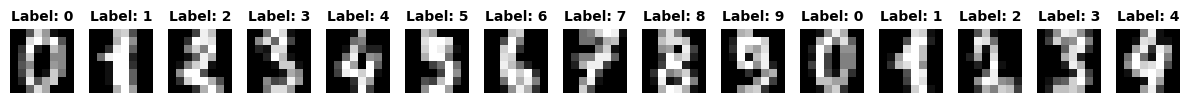

In [9]:
#Load the Handwritten Digits Dataset
digits=load_digits()

x_raw=digits.images #8x8 pixel images (features)
y_raw=digits.target # True numeriacal labels (0 to 9) (target)

print(f"Total Handwritten Images in Dataset: {len(x_raw)}")
print(f"Single Image Shape: {x_raw[0].shape} (8 rows by 8 columns)")

#Show the first 5 handwritten digits in the dataset
show_digit_grid(x_raw[:15],y_raw[:15],cols=15)

In [15]:
#Inspecting pixel numbers of digit '0'
sample_digit=x_raw[0]
print("--- Pixel Matrix of Handwritten Digit '0' ---")
print(sample_digit.astype(int))

print(f"Min Pixel Instensity (Background): {sample_digit.min()}")
print(f"Max Pixel Intensity (Ink): {sample_digit.max()}")

--- Pixel Matrix of Handwritten Digit '0' ---
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]
Min Pixel Instensity (Background): 0.0
Max Pixel Intensity (Ink): 15.0
